# 26. K-Means Clustering Project

## Project Introduction

In this project, we will apply the K-Means Clustering algorithm to the Iris dataset.  
The aim of this project is to group flowers into clusters based on their numerical features without using the target labels during training.

K-Means is an unsupervised machine learning algorithm. It tries to divide data points into a selected number of clusters by minimizing the distance between each point and its cluster center.

## Project Roadmap

1. Import required libraries  
2. Load the Iris dataset  
3. Prepare the feature data  
4. Standardize the data  
5. Use the Elbow Method to find the best number of clusters  
6. Train the K-Means model  
7. Add cluster labels to the dataset  
8. Visualize the clusters  
9. Compare clusters with real Iris classes  
10. Save the trained model  
11. Write project conclusion

In [1]:
# Gerekli kütüphaneleri içe aktarıyoruz
import pandas as pd, matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [2]:
# Iris veri setini yüklüyor ve tabloya çeviriyoruz
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
# Veri setinin genel yapısını kontrol ediyoruz
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [4]:
# Kümeleme için sadece sayısal özellikleri seçiyoruz
X = df.copy()
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
# Veriyi standartlaştırıyoruz
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
# Elbow yöntemi için farklı küme sayılarını deniyoruz
from sklearn.cluster import KMeans
inertia = []

In [7]:
# Her k değeri için model kurup hata değerini kaydediyoruz
for k in range(1, 11):
    inertia.append(KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled).inertia_)

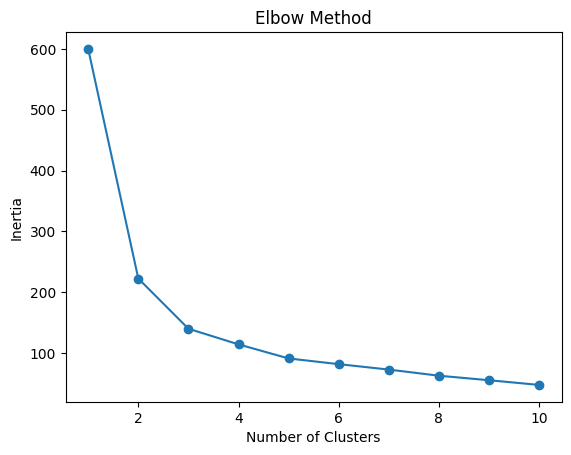

In [8]:
# Elbow grafiğini çiziyoruz
plt.plot(range(1, 11), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

## Elbow Method Result

The Elbow Method helps us decide the best number of clusters for K-Means.  
In the graph, the decrease in inertia slows down around **3 clusters**.

Since the Iris dataset naturally contains three flower species, choosing **k = 3** is a reasonable decision for this project.

In [9]:
# K-Means modelini 3 küme ile eğitiyoruz
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

## Model Training

In this step, the K-Means algorithm was trained with 3 clusters.  
The model assigned each flower sample to one of the three clusters based only on its numerical features.

The original Iris class labels were not used during model training.

In [10]:
# Bulunan küme etiketlerini veri setine ekliyoruz
df["Cluster"] = clusters
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


## Cluster Visualization

In this step, we visualize the clusters created by the K-Means algorithm.  
For visualization, we use two features from the Iris dataset: sepal length and sepal width.

Each color represents a different cluster assigned by the model.

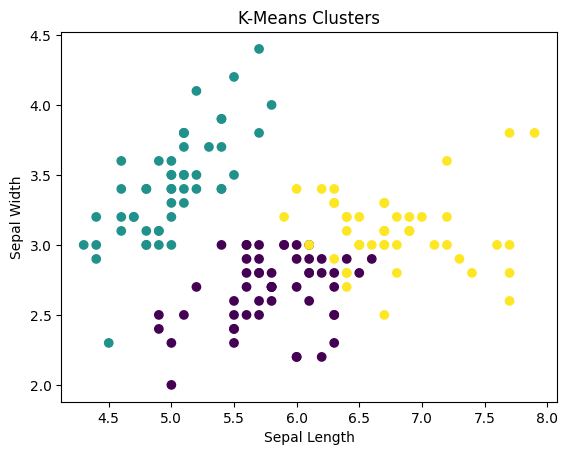

In [11]:
# K-Means kümelerini iki özellik üzerinden görselleştiriyoruz
plt.scatter(df["sepal length (cm)"], df["sepal width (cm)"], c=df["Cluster"])
plt.xlabel("Sepal Length"); plt.ylabel("Sepal Width"); plt.title("K-Means Clusters")
plt.show()

## Visualization Comment

The scatter plot shows how K-Means separated the data points into three groups.  
Since K-Means is an unsupervised algorithm, it does not know the real flower species during training.  
It only groups samples according to feature similarity.

In [12]:
# Gerçek Iris sınıflarını karşılaştırma için veri setine ekliyoruz
df["Actual_Class"] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster,Actual_Class
0,5.1,3.5,1.4,0.2,1,0
1,4.9,3.0,1.4,0.2,1,0
2,4.7,3.2,1.3,0.2,1,0
3,4.6,3.1,1.5,0.2,1,0
4,5.0,3.6,1.4,0.2,1,0


In [13]:
# Gerçek sınıflar ile bulunan kümeleri karşılaştırıyoruz
pd.crosstab(df["Actual_Class"], df["Cluster"])

Cluster,0,1,2
Actual_Class,,,
0,0,50,0
1,39,0,11
2,14,0,36


## Cluster and Real Class Comparison

In this step, we compare the clusters created by K-Means with the actual Iris classes.

However, cluster numbers do not directly represent class names.  
For example, Cluster 0 does not necessarily mean Iris Setosa.  
K-Means only groups similar samples together, and the cluster labels are assigned automatically.

In [14]:
# Kümeleme başarısını Adjusted Rand Score ile ölçüyoruz
from sklearn.metrics import adjusted_rand_score
adjusted_rand_score(df["Actual_Class"], df["Cluster"])

0.6201351808870379

## Evaluation Result

The Adjusted Rand Score compares the clustering result with the actual Iris classes.  
A higher score means that the clusters are more similar to the real classes.

In this project, K-Means performed reasonably well because the Iris dataset has naturally separable groups, especially for one of the flower species.

In [15]:
# Eğitilen K-Means modelini ve scaler nesnesini kaydediyoruz
import joblib
joblib.dump(kmeans, "kmeans_iris_model.pkl")
joblib.dump(scaler, "kmeans_iris_scaler.pkl")

['kmeans_iris_scaler.pkl']

## Model Saving

The trained K-Means model and the StandardScaler object were saved using joblib.  
Saving the model allows us to use it later in a Streamlit web application without training it again.

In [16]:
# Kaydedilen model dosyalarını kontrol ediyoruz
import os
[f for f in os.listdir() if f.endswith(".pkl")]

['kmeans_iris_scaler.pkl', 'kmeans_iris_model.pkl']

## Streamlit Application

In this step, we create a simple Streamlit application.  
The user can enter Iris flower measurements, and the saved K-Means model predicts the cluster of the flower.

In [17]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

model = joblib.load("kmeans_iris_model.pkl")
scaler = joblib.load("kmeans_iris_scaler.pkl")

st.title("K-Means Clustering - Iris Project")
st.write("This app predicts the cluster of an Iris flower using a trained K-Means model.")

sepal_length = st.slider("Sepal Length (cm)", 4.0, 8.0, 5.1)
sepal_width = st.slider("Sepal Width (cm)", 2.0, 4.5, 3.5)
petal_length = st.slider("Petal Length (cm)", 1.0, 7.0, 1.4)
petal_width = st.slider("Petal Width (cm)", 0.1, 2.5, 0.2)

data = pd.DataFrame(
    [[sepal_length, sepal_width, petal_length, petal_width]],
    columns=[
        "sepal length (cm)",
        "sepal width (cm)",
        "petal length (cm)",
        "petal width (cm)"
    ]
)

scaled_data = scaler.transform(data)
cluster = model.predict(scaled_data)[0]

st.subheader("Prediction Result")
st.write("Predicted Cluster:", cluster)

Writing app.py


## Requirements File

A requirements.txt file is needed for Streamlit and Hugging Face Spaces.  
This file tells the platform which Python libraries are required to run the project.

In [18]:
%%writefile requirements.txt
streamlit
pandas
scikit-learn
joblib
matplotlib

Writing requirements.txt


## Project README

The README file explains the purpose of the project, the algorithm used, and how the application works.  
This file is useful for GitHub and Hugging Face project pages.

In [19]:
%%writefile README.md
# K-Means Clustering Project

## Project Description

This project applies the K-Means Clustering algorithm to the Iris dataset.

The aim is to group Iris flower samples into clusters based on their numerical features without using the original class labels during model training.

## Dataset

The Iris dataset contains flower measurements:

- Sepal length
- Sepal width
- Petal length
- Petal width

## Method

The project includes the following steps:

1. Loading the Iris dataset
2. Preparing numerical features
3. Standardizing the data
4. Finding the best number of clusters with the Elbow Method
5. Training the K-Means model
6. Visualizing the clusters
7. Comparing clusters with actual Iris classes
8. Saving the trained model
9. Creating a Streamlit web application

## Model

The trained model was saved as:

- kmeans_iris_model.pkl
- kmeans_iris_scaler.pkl

## Streamlit App

The Streamlit app allows users to enter Iris flower measurements and predicts the cluster of the flower.

## Conclusion

K-Means was able to group the Iris samples into three clusters.  
The results were compared with the actual Iris classes using Adjusted Rand Score.

Writing README.md


## Project Files Check

In this step, we check whether all required project files were created successfully.

The project should include the trained model files, the Streamlit application file, the requirements file, and the README file.

In [20]:
# Proje için oluşturulan dosyaları kontrol ediyoruz
import os
os.listdir()

['app.py',
 'requirements.txt',
 'kmeans_iris_scaler.pkl',
 'kmeans_iris_model.pkl',
 '__notebook__.ipynb',
 'README.md']

## Final Conclusion

In this project, K-Means Clustering was applied to the Iris dataset.

The data was first standardized because K-Means is a distance-based algorithm.  
Then, the Elbow Method was used to choose the number of clusters.  
According to the Elbow Method, 3 clusters were selected.

After training the model, the cluster labels were added to the dataset and visualized using a scatter plot.  
The clustering results were also compared with the actual Iris classes using Adjusted Rand Score.

Finally, the trained K-Means model and scaler were saved with joblib.  
A Streamlit application, requirements file, and README file were also created for deployment.

This project shows how unsupervised learning can be used to discover hidden groups in a dataset without using target labels during training.